# ColonySearch — Figure Generation

Standalone notebook that produces all publication-ready figures for the thesis.

| Figure | File | Source |
|--------|------|--------|
| Body-length distribution | `figures/corpus-length-dist.png` | `data/corpus/*.json` |
| Tag word cloud | `figures/tag-wordcloud.png` | `ai_labels` field in corpus |
| Param sensitivity heatmap | `figures/param-sensitivity-heatmap.png` | `tuning/grid_search_results.json` |

**Run order:** execute all cells top-to-bottom.  
The heatmap cell requires `tuning/grid_search_results.json` — run `tuning/benchmark.ipynb` first to generate it.

In [1]:
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR    = Path(".")          # data/
CORPUS_DIR  = DATA_DIR / "corpus"
FIGURES_DIR = DATA_DIR / "figures"
GRID_LOG    = DATA_DIR / "tuning" / "grid_search_results.json"

# ── Body-length histogram ──────────────────────────────────────────────────
MIN_BODY_LEN = 150   # must match data_preperation.ipynb
HIST_BINS    = 60

# ── Figure output ──────────────────────────────────────────────────────────
DPI = 150

FIGURES_DIR.mkdir(exist_ok=True)
print("Config OK — figures will be written to:", FIGURES_DIR.resolve())

Config OK — figures will be written to: /home/lukas/Documents/Uni/THN/IntroBC/ColonySearch/data/figures


## 1 — Load corpus

In [2]:
import json
import ast
import html
import re
import numpy as np
import pandas as pd

_MOJIBAKE = {
    "\u00c2\u00b6": "\u00b6",
    "\u00e2\u20ac\u2122": "'",
    "\u00e2\u20ac\u0153": '"',
    "\u00e2\u20ac\u009d": '"',
    "\u00e2\u20ac\u201c": "\u2013",
    "\u00e2\u20ac\u201d": "\u2014",
    "\u00e2\u20ac\u00a6": "\u2026",
    "\u00c2\u00a9": "\u00a9",
    "\u00c2\u00ae": "\u00ae",
    "\u00c2\u00b7": "\u00b7",
    "\u00c2\u00a0": " ",
}
_BOILERPLATE = re.compile(
    r"Loading component\.{0,3}"
    r"|Past Events\s+View Upcoming"
    r"|Please enable JavaScript"
    r"|Cookie\s+(Policy|Settings|Notice)",
    re.IGNORECASE,
)

def clean_text(text: str) -> str:
    if not text:
        return ""
    text = html.unescape(text)
    for bad, good in _MOJIBAKE.items():
        text = text.replace(bad, good)
    text = re.sub(r"<[^>]{1,200}>", " ", text)
    text = _BOILERPLATE.sub(" ", text)
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

records = []
for path in sorted(CORPUS_DIR.glob("*.json")):
    try:
        doc = json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        continue
    prefix = path.name.split("__")[0] if "__" in path.name else "(no prefix)"
    labels = doc.get("ai_labels", [])
    if isinstance(labels, str):
        try:
            labels = ast.literal_eval(labels)
        except Exception:
            labels = []
    records.append({
        "file":         path.name,
        "topic_prefix": prefix,
        "body_clean":   clean_text(doc.get("body", "")),
        "ai_labels":    labels if isinstance(labels, list) else [],
    })

df = pd.DataFrame(records)
df["body_len"] = df["body_clean"].str.len()

clean = df[df["body_len"] >= MIN_BODY_LEN].copy().reset_index(drop=True)
print(f"Total files loaded : {len(df)}")
print(f"After MIN_BODY_LEN : {len(clean)}")

Total files loaded : 1574
After MIN_BODY_LEN : 1555


## 2 — Body-length distribution

Reproduces the quality-filter histogram from `data_preperation.ipynb` as a
standalone, publication-ready figure.

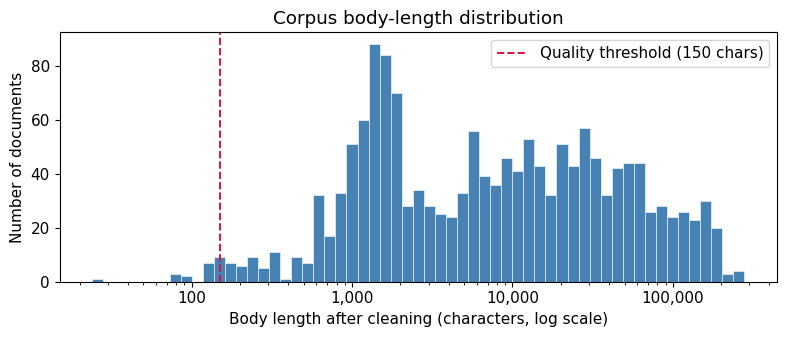

Saved → figures/corpus-length-dist.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({"font.size": 11})

fig, ax = plt.subplots(figsize=(8, 3.5))

plot_len = df["body_len"][df["body_len"] > 0]
bins = np.logspace(np.log10(plot_len.min()), np.log10(plot_len.max()), HIST_BINS)
ax.hist(plot_len, bins=bins, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(MIN_BODY_LEN, color="crimson", linestyle="--", linewidth=1.4,
           label=f"Quality threshold ({MIN_BODY_LEN} chars)")

ax.set_xscale("log")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f"{int(x):,}" if x >= 1 else f"{x:.1f}"
))
ax.set_xlabel("Body length after cleaning (characters, log scale)")
ax.set_ylabel("Number of documents")
ax.set_title("Corpus body-length distribution")
ax.legend()
plt.tight_layout()

out = FIGURES_DIR / "corpus-length-dist.png"
fig.savefig(out, dpi=DPI)
plt.show()
print(f"Saved → {out}")

## 3 — Tag word cloud

Visualises the full `ai_labels` tag vocabulary weighted by frequency.

```python
# from wordcloud import WordCloud
# Suggested filename: figures/tag-wordcloud.png
```

Unique tags : 3484
Total tag instances : 10146
Top 15: [('history', 209), ('machine learning', 161), ('medicine', 144), ('physics', 125), ('programming', 112), ('climate change', 111), ('sports', 102), ('politics', 100), ('economics', 90), ('geography', 89), ('engineering', 89), ('football', 88), ('biology', 83), ('energy', 82), ('artificial intelligence', 71)]


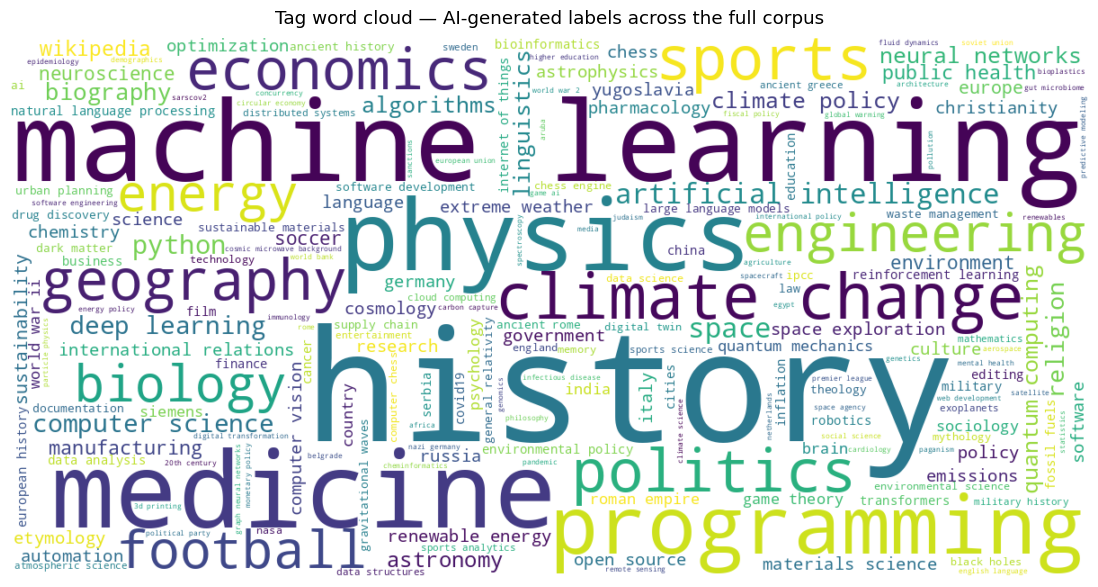

Saved → figures/tag-wordcloud.png


In [5]:
from collections import Counter
from wordcloud import WordCloud

# Collect every tag from the full corpus (not just the clean subset)
all_tags: list[str] = []
for labels in df["ai_labels"]:
    all_tags.extend(labels)

tag_freq = Counter(all_tags)
print(f"Unique tags : {len(tag_freq)}")
print(f"Total tag instances : {sum(tag_freq.values())}")
print("Top 15:", tag_freq.most_common(15))

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=200,
    prefer_horizontal=0.85,
    min_font_size=8,
    collocations=False,   # treat multi-word tags as atomic
).generate_from_frequencies(tag_freq)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Tag word cloud — AI-generated labels across the full corpus", pad=10)
plt.tight_layout()

out = FIGURES_DIR / "tag-wordcloud.png"
fig.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

## 4 — Parameter sensitivity heatmap

Plots NDCG@3 across `alpha × link_bias` from the Grid Search run in
`tuning/benchmark.ipynb`.  `svd_dims` is fixed at the value that appeared
most in the top results.

```python
# x-axis: alpha values in the grid
# y-axis: link_bias values in the grid
# color:  NDCG@3 at that combination
# Suggested filename: figures/param-sensitivity-heatmap.png
```

> **Prerequisite:** run `tuning/benchmark.ipynb` at least once so that
> `tuning/grid_search_results.json` exists.

Grid shape  : (5, 5)  (link_bias x alpha)
svd_dims    : 8
NDCG@3 range : 0.3532 - 0.8607


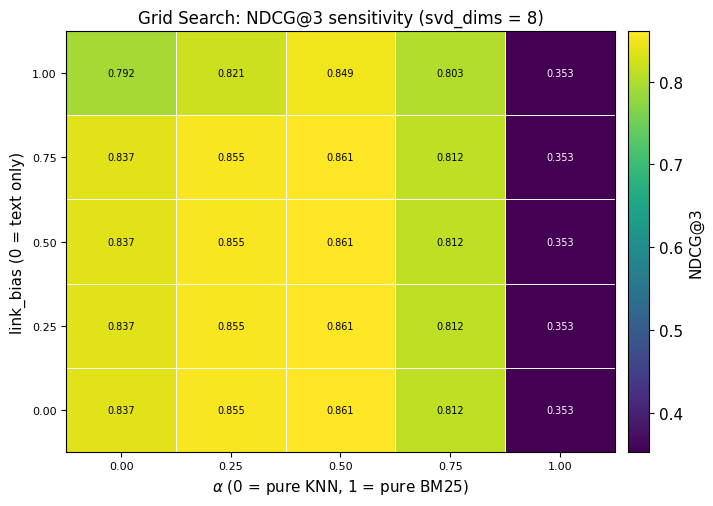

Saved -> figures/param-sensitivity-heatmap.png


In [7]:
import json as _json
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

if not GRID_LOG.exists():
    raise FileNotFoundError(
        f"{GRID_LOG} not found.\n"
        "Run tuning/benchmark.ipynb first - it saves the grid results automatically."
    )

grid_data = _json.loads(GRID_LOG.read_text())

ndcg_grid  = np.array(grid_data["ndcg_grid"])   # shape (n_lb, n_alpha)
lb_vals    = np.array(grid_data["lb_vals"])
alpha_vals = np.array(grid_data["alpha_vals"])
svd_fixed  = int(grid_data["svd_dims_fixed"])
k          = int(grid_data.get("k", 3))

print(f"Grid shape  : {ndcg_grid.shape}  (link_bias x alpha)")
print(f"svd_dims    : {svd_fixed}")
print(f"NDCG@{k} range : {ndcg_grid.min():.4f} - {ndcg_grid.max():.4f}")

n_lb, n_al = ndcg_grid.shape
fig, ax = plt.subplots(figsize=(7.5, 5.2))

norm = mcolors.Normalize(vmin=ndcg_grid.min(), vmax=ndcg_grid.max())
im = ax.imshow(
    ndcg_grid,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    norm=norm,
    interpolation="nearest",
 )
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label(f"NDCG@{k}", fontsize=11)

ax.set_xticks(np.arange(n_al))
ax.set_yticks(np.arange(n_lb))
ax.set_xticklabels([f"{v:.2f}" for v in alpha_vals], fontsize=8)
ax.set_yticklabels([f"{v:.2f}" for v in lb_vals], fontsize=8)

# Cell boundaries for easier reading
ax.set_xticks(np.arange(-0.5, n_al, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_lb, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.7)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(n_lb):
    for j in range(n_al):
        val = ndcg_grid[i, j]
        text_color = "white" if norm(val) < 0.45 else "black"
        ax.text(j, i, f"{val:.3f}",
                ha="center", va="center", fontsize=7, color=text_color)

ax.set_xlabel(r"$\alpha$ (0 = pure KNN, 1 = pure BM25)", fontsize=11)
ax.set_ylabel("link_bias (0 = text only)", fontsize=11)
ax.set_title(f"Grid Search: NDCG@{k} sensitivity (svd_dims = {svd_fixed})", fontsize=12)

plt.tight_layout()

out = FIGURES_DIR / "param-sensitivity-heatmap.png"
fig.savefig(out, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved -> {out}")

In [10]:
# Topic distribution for cleaned corpus (LaTeX rows)
topic_labels = {
    "climate_change": "Climate Change",
    "sustainable_materials": "Sustainable Materials",
    "space": "Space",
    "programming": "Programming",
    "ml_algorithms": "Machine Learning",
    "football": "Football",
    "quantum_computing": "Quantum Computing",
    "medicine": "Medicine",
    "economics": "Economics",
    "neuroscience": "Neuroscience",
    "smart_manufacturing": "Smart Manufacturing",
}

order = list(topic_labels.values())
counts = (
    clean["topic_prefix"]
    .map(topic_labels)
    .fillna(clean["topic_prefix"])
    .value_counts()
)
ordered = counts.reindex(order).fillna(0).astype(int)
total = int(ordered.sum())

unknown = sorted(set(clean["topic_prefix"]) - set(topic_labels))
if unknown:
    print("Unknown topic prefixes:", unknown)

print("Topic & Documents \\")
print("\\midrule")
for topic, count in ordered.items():
    print(f"{topic} & {count} \\")
print("\\midrule")
print(f"\\textbf{{Total}} & \\textbf{{{total}}} \\")

Topic & Documents \
\midrule
Climate Change & 168 \
Sustainable Materials & 61 \
Space & 196 \
Programming & 78 \
Machine Learning & 126 \
Football & 186 \
Quantum Computing & 59 \
Medicine & 117 \
Economics & 181 \
Neuroscience & 106 \
Smart Manufacturing & 277 \
\midrule
\textbf{Total} & \textbf{1555} \


In [9]:
# Tag statistics for LaTeX text
def _tag_count(x):
    return len(x) if isinstance(x, list) else 0

all_tags_per_doc = df["ai_labels"].map(_tag_count)
clean_tags_per_doc = clean["ai_labels"].map(_tag_count)

print("All docs - min/max/mean:",
      int(all_tags_per_doc.min()),
      int(all_tags_per_doc.max()),
      f"{all_tags_per_doc.mean():.2f}")
print("Clean docs - min/max/mean:",
      int(clean_tags_per_doc.min()),
      int(clean_tags_per_doc.max()),
      f"{clean_tags_per_doc.mean():.2f}")

All docs - min/max/mean: 3 12 6.45
Clean docs - min/max/mean: 4 12 6.46


In [12]:
# Share of cleaned docs with at least one tag not matching scrape category
def _norm_label(s: str) -> str:
    return "".join(ch for ch in s.lower() if ch.isalnum())

# Normalize topic names and prefixes for comparison
topic_norm = {
    _norm_label(k): _norm_label(v)
    for k, v in topic_labels.items()
}

def _expected_label(prefix: str) -> str:
    return topic_norm.get(_norm_label(prefix), "")

def _has_nonmatching_tag(row) -> bool:
    expected = _expected_label(row["topic_prefix"])
    if not expected:
        return False
    labels = row["ai_labels"] if isinstance(row["ai_labels"], list) else []
    norm_labels = [
        _norm_label(lbl)
        for lbl in labels
        if isinstance(lbl, str) and _norm_label(lbl)
    ]
    return any(lbl != expected for lbl in norm_labels)

nonmatching = clean.apply(_has_nonmatching_tag, axis=1)
count = int(nonmatching.sum())
total = int(len(clean))
pct = (count / total * 100) if total else 0.0

print(f"Non-matching tag docs: {count}/{total} ({pct:.2f}%)")

Non-matching tag docs: 1555/1555 (100.00%)
